In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import sklearn
import xgboost

print("All libraries are ready!")

C:\Users\shubh\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


All libraries are ready!


In [2]:
import ee
ee.Authenticate()

True

In [3]:
ee.Initialize(project='spheric-gasket-507711-f8')
print(ee.Number(10).getInfo())

10


In [4]:
states = ee.FeatureCollection('FAO/GAUL/2015/level1')
ner_names = ['Assam',]
ner = states.filter(
    ee.Filter.inList('ADM1_NAME', ner_names)
)
print("Number of NER states:", ner.size().getInfo())

Number of NER states: 1


In [5]:
import geemap
Map = geemap.Map()
Map.center_object(ner, 6)
Map.add_layer(
    ner,
    {},
    "NER Boundary"
)
Map

Map(center=[26.352060685710303, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

In [6]:
# SRTM Elevation
dem = ee.Image('USGS/SRTMGL1_003').clip(ner)

# Slope
slope = ee.Terrain.slope(dem)

print("DEM and Slope loaded successfully!")

DEM and Slope loaded successfully!


In [7]:
Map.add_layer(
    dem,
    {'min': 0, 'max': 3000},
    'Elevation'
)

Map.add_layer(
    slope,
    {'min': 0, 'max': 60},
    'Slope'
)

Map

Map(bottom=3828.0, center=[24.225815433567107, 96.72199155220467], controls=(WidgetControl(options=['position'…

In [8]:
# MODIS NDVI - 2024
ndvi_collection = ee.ImageCollection('MODIS/061/MOD13Q1') \
    .filterDate('2024-01-01', '2025-01-01') \
    .select('NDVI')

# 2024 ka average NDVI
ndvi = ndvi_collection.mean().clip(ner)

print("NDVI loaded successfully!")

NDVI loaded successfully!


In [9]:
Map.add_layer(
    ndvi,
    {
        'min': 0,
        'max': 8000
    },
    'NDVI 2024'
)

Map

Map(bottom=3828.0, center=[24.225815433567107, 96.72199155220467], controls=(WidgetControl(options=['position'…

In [10]:
# CHIRPS Daily Rainfall - 2024
rainfall_collection = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
    .filterDate('2024-01-01', '2025-01-01') \
    .select('precipitation')

# Average daily rainfall for 2024
rainfall = rainfall_collection.mean().clip(ner)

print("Rainfall loaded successfully!")

Rainfall loaded successfully!


In [11]:
Map.add_layer(
    rainfall,
    {
        'min': 0,
        'max': 10
    },
    'Rainfall 2024'
)

Map

Map(bottom=3828.0, center=[24.225815433567107, 96.72199155220467], controls=(WidgetControl(options=['position'…

In [12]:
landcover = ee.Image('ESA/WorldCover/v100/2020').clip(ner)

print("Land Cover loaded successfully!")

Land Cover loaded successfully!


In [13]:
Map.add_layer(
    landcover,
    {},
    'Land Cover 2020'
)

Map

Map(bottom=3828.0, center=[24.225815433567107, 96.72199155220467], controls=(WidgetControl(options=['position'…

In [14]:
# Soil Clay Content
soil_clay = ee.Image(
    'projects/soilgrids-isric/clay_mean'
).select('clay_0-5cm_mean').clip(ner)

print("Soil clay data loaded successfully!")

Soil clay data loaded successfully!


In [15]:
Map.add_layer(
    soil_clay,
    {
        'min': 0,
        'max': 500
    },
    'Soil Clay 0-5cm'
)

Map

Map(bottom=3828.0, center=[24.225815433567107, 96.72199155220467], controls=(WidgetControl(options=['position'…

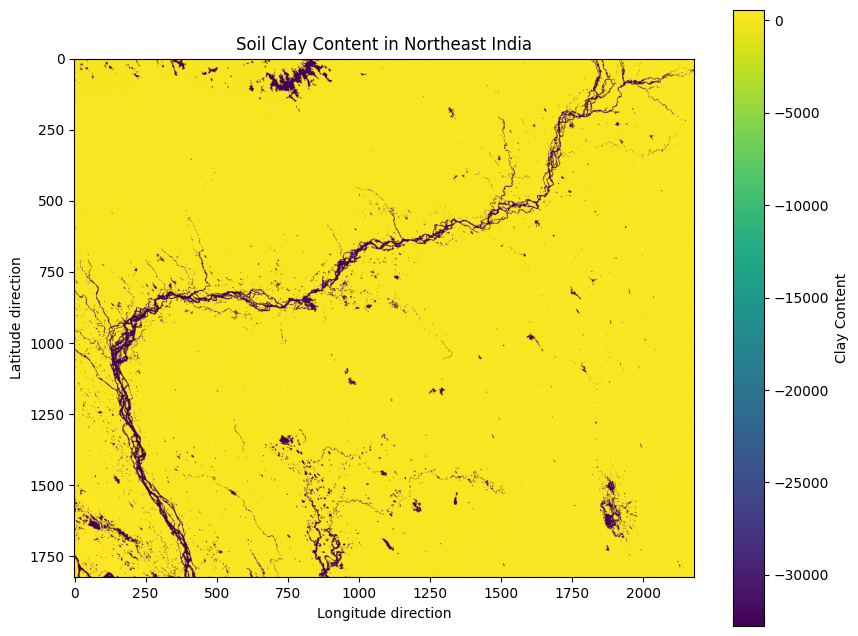

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Soil clay data ko NER region se NumPy array me convert karo
soil_array = geemap.ee_to_numpy(
    soil_clay,
    region=ner.geometry(),
    scale=250
)

# 2D array banao
soil_data = soil_array[:, :, 0]

# Matplotlib plot
plt.figure(figsize=(10, 8))

plt.imshow(soil_data)
plt.colorbar(label='Clay Content')

plt.title('Soil Clay Content in Northeast India')
plt.xlabel('Longitude direction')
plt.ylabel('Latitude direction')

plt.show()

In [18]:
import ee

slope = ee.Terrain.slope(dem)

print("Slope calculated successfully!")

Slope calculated successfully!


In [19]:
Map.add_layer(
    slope,
    {
        'min': 0,
        'max': 60
    },
    'Slope'
)

Map

Map(bottom=3828.0, center=[24.225815433567107, 96.72199155220467], controls=(WidgetControl(options=['position'…

In [29]:
from shapely.geometry import shape

# NER boundary ko GeoJSON/Shapely geometry mein convert karo
ner_geojson = ner.geometry().getInfo()
ner_shape = shape(ner_geojson)

print("NER boundary converted successfully!")

NER boundary converted successfully!


In [30]:
import ee
from shapely.validation import make_valid

# Sirf Assam select karo
assam = states.filter(
    ee.Filter.eq('ADM1_NAME', 'Assam')
)
# Geometry fix
polygon = make_valid(polygon)

print("Assam geometry:", polygon.geom_type)
print("Valid:", polygon.is_valid)

Assam geometry: Polygon
Valid: True


In [31]:
import geopandas as gpd
from shapely.geometry import box

# Assam polygon ko GeoDataFrame mein convert karo
assam_gdf = gpd.GeoDataFrame(
    {"name": ["Assam"]},
    geometry=[polygon],
    crs="EPSG:4326"
)

# Assam ka bounding box
minx, miny, maxx, maxy = polygon.bounds

# 4 x 4 grid
nx = 4
ny = 4

x_step = (maxx - minx) / nx
y_step = (maxy - miny) / ny

grid = []

for i in range(nx):
    for j in range(ny):
        cell = box(
            minx + i * x_step,
            miny + j * y_step,
            minx + (i + 1) * x_step,
            miny + (j + 1) * y_step
        )

        if cell.intersects(polygon):
            grid.append(cell.intersection(polygon))

print("Total Assam parts:", len(grid))

Total Assam parts: 11


In [32]:
df = pd.read_csv("landslide_report.csv")

In [33]:
df = pd.read_csv(
    r"C:\Users\shubh\OneDrive\Documents\hack\assam_report_updated.csv"
)

In [34]:
print(df.columns.tolist())
print(df.shape)

['Sl.No.', 'Slide_No', 'State', 'District', 'Slide_Name', 'NH_SH_Location', 'Latitude', 'Longitude', 'Material Involved', 'Movement\nType', 'History']
(36072, 11)


In [38]:
import geopandas as gpd
import pandas as pd

# Latitude/Longitude numeric
df["Latitude"] = pd.to_numeric(
    df["Latitude"], errors="coerce"
)

df["Longitude"] = pd.to_numeric(
    df["Longitude"], errors="coerce"
)

# Sirf Assam
assam = df[df["State"] == "Assam"].copy()

# Invalid coordinates remove
assam = assam.dropna(
    subset=["Latitude", "Longitude"]
)

# Points create
assam_gdf = gpd.GeoDataFrame(
    assam,
    geometry=gpd.points_from_xy(
        assam["Longitude"],
        assam["Latitude"]
    ),
    crs="EPSG:4326"
)


In [39]:
import ee

# Whole Assam ke landslide points ko GEE FeatureCollection me convert karo
features = []

for _, row in assam_gdf.iterrows():

    point = ee.Geometry.Point([
        float(row["Longitude"]),
        float(row["Latitude"])
    ])

    features.append(
        ee.Feature(
            point,
            {
                "landslide": 1,
                "Latitude": float(row["Latitude"]),
                "Longitude": float(row["Longitude"])
            }
        )
    )

landslide_points_ee = ee.FeatureCollection(features)

print(
    "Whole Assam GEE landslide points:",
    landslide_points_ee.size().getInfo()
)

Whole Assam GEE landslide points: 856


In [40]:
# NDVI ko actual scale me convert karo
ndvi_scaled = ndvi.multiply(0.0001)

# Saare environmental features combine
feature_image = (
    dem.rename("Elevation")
    .addBands(slope.rename("Slope"))
    .addBands(rainfall.rename("Rainfall"))
    .addBands(ndvi_scaled.rename("NDVI"))
    .addBands(soil_clay.rename("SoilClay"))
    .addBands(landcover.rename("LandCover"))
)

print("Environmental feature image ready!")

Environmental feature image ready!


In [41]:
# Saare environmental features combine
feature_image

In [42]:
sampled = feature_image.sampleRegions(
    collection=landslide_points_ee,
    properties=["landslide", "Latitude", "Longitude"],
    scale=30,
    geometries=True
)

sampled_df = geemap.ee_to_df(sampled)

print(sampled_df.shape)
sampled_df.head()

(765, 9)


,Elevation,LandCover,Latitude,Longitude,NDVI,Rainfall,Slope,SoilClay,landslide
0,41,10,24.27,92.50,0.629852,10.344681,11.042389,273,1
1,46,10,24.31,92.56,0.610804,10.613641,2.751801,277,1
2,81,10,24.32,92.51,0.745065,10.591166,8.876157,275,1
3,38,40,24.43,92.55,0.617457,10.739355,4.125875,281,1
4,201,10,24.44,92.50,0.752230,10.404755,27.323839,280,1


In [46]:
import pandas as pd

file_path = r"C:\Users\shubh\OneDrive\Documents\hack\assam_report_GEE.csv"

landslides = pd.read_csv(file_path)

print("Total landslide records:", len(landslides))
print(landslides.columns.tolist())
landslides.head()

Total landslide records: 36072
['Sl.No.', 'Slide_No', 'State', 'District', 'Slide_Name', 'NH_SH_Location', 'Latitude', 'Longitude', 'Material Involved', 'Movement_Type', 'History']


,Sl.No.,Slide_No,State,District,Slide_Name,NH_SH_Location,Latitude,Longitude,Material Involved,Movement_Type,History
0,1,ASM/HKN/83D07/2020/2,Assam,Hailakandi,Kukinala slide,Kukinala,24.27,92.50,Debris,Slide,NaN
1,2,AS/HKN/83D11/2020/1,Assam,Hailakandi,Jalnachaura slide,Jalnachaura,24.31,92.56,Debris,Slide,NaN
2,3,AS/HKN/83D10/2020/6,Assam,Hailakandi,Nandagram slide,Nandagram Pt. I,24.32,92.51,Debris,Slide,NaN
3,4,AS/HKN/83D11/2020/4,Assam,Hailakandi,Nishkar slide,Mahapur,24.43,92.55,Debris,Slide,NaN
4,5,AS/KRJ/83D07/2020/1,Assam,Karimganj,Paglacherra slide,PaglacherraPunj,24.44,92.50,Rock,Slide,NaN


In [47]:
landslides = landslides[
    landslides["State"].astype(str).str.strip().str.lower() == "assam"
].copy()

landslides["Latitude"] = pd.to_numeric(
    landslides["Latitude"], errors="coerce"
)

landslides["Longitude"] = pd.to_numeric(
    landslides["Longitude"], errors="coerce"
)

landslides = landslides.dropna(
    subset=["Latitude", "Longitude"]
).reset_index(drop=True)

print("Assam landslide records:", len(landslides))

Assam landslide records: 856


In [49]:
import numpy as np
from shapely.geometry import Point

np.random.seed(42)

n_negative = 1000
negative_points = []

# Historical GSI landslide coordinates
landslide_geom = [
    Point(float(lon), float(lat))
    for lon, lat in zip(
        landslides["Longitude"],
        landslides["Latitude"]
    )
]

# Equal background sampling across Assam grid
base_points = n_negative // len(grid)
remainder = n_negative % len(grid)

for i, cell in enumerate(grid):

    target_points = base_points + (1 if i < remainder else 0)

    minx, miny, maxx, maxy = cell.bounds

    while sum(
        1 for p in negative_points
        if cell.contains(p)
    ) < target_points:

        lon = np.random.uniform(minx, maxx)
        lat = np.random.uniform(miny, maxy)

        point = Point(lon, lat)

        if not cell.contains(point):
            continue

        # Avoid sampling too close to known landslide locations
        too_close = any(
            point.distance(ls) < 0.005
            for ls in landslide_geom
        )

        if not too_close:
            negative_points.append(point)

print("Whole Assam background points:", len(negative_points))

Whole Assam background points: 1000


In [50]:
negative_features = []

for point in negative_points:
    negative_features.append(
        ee.Feature(
            ee.Geometry.Point([point.x, point.y]),
            {
                "landslide": 0,
                "Latitude": point.y,
                "Longitude": point.x
            }
        )
    )

non_landslide_points_ee = ee.FeatureCollection(
    negative_features
)

print(
    "GEE non-landslide points:",
    non_landslide_points_ee.size().getInfo()
)

GEE non-landslide points: 1000


In [61]:
negative_sampled = feature_image.sampleRegions(
    collection=negative_points_ee,
    properties=["landslide", "Latitude", "Longitude"],
    scale=30,
    geometries=False,
    tileScale=4
)

negative_df = geemap.ee_to_df(negative_sampled)

print("Non-landslide samples:", len(negative_df))
print(negative_df.head())

Non-landslide samples: 956
   Elevation  LandCover   Latitude  Longitude      NDVI  Rainfall     Slope  \
0         26         40  25.978015  89.863184  0.499257  7.307900  1.387071   
1         32         40  26.038513  89.806924  0.587743  6.723338  0.927410   
2         28         40  26.026251  89.873638  0.486596  6.572965  2.121836   
3         53         40  25.944318  91.224795  0.617648  5.637803  3.704792   
4         27         40  26.003177  89.827634  0.379065  6.723338  1.387236   

   SoilClay  landslide  
0       341          0  
1       302          0  
2       275          0  
3       288          0  
4       276          0  


In [62]:
# Positive + Negative samples combine
ml_data = pd.concat(
    [sampled_df, negative_df],
    ignore_index=True
)

print("Total samples:", len(ml_data))
print("Landslide samples:", (ml_data["landslide"] == 1).sum())
print("Non-landslide samples:", (ml_data["landslide"] == 0).sum())

ml_data

Total samples: 1721
Landslide samples: 765
Non-landslide samples: 956


,Elevation,LandCover,Latitude,Longitude,NDVI,Rainfall,Slope,SoilClay,landslide
0,41,10,24.270000,92.500000,0.629852,10.344681,11.042389,273,1
1,46,10,24.310000,92.560000,0.610804,10.613641,2.751801,277,1
2,81,10,24.320000,92.510000,0.745065,10.591166,8.876157,275,1
3,38,40,24.430000,92.550000,0.617457,10.739355,4.125875,281,1
4,201,10,24.440000,92.500000,0.752230,10.404755,27.323839,280,1
...,...,...,...,...,...,...,...,...,...
1716,103,10,27.216092,94.900346,0.640265,7.063287,0.927410,256,0
1717,115,40,27.464670,95.179655,0.669709,6.921876,2.089676,253,0
1718,115,40,27.429784,95.210014,0.519539,7.062295,0.927410,276,0
1719,168,10,27.398929,95.656292,0.751700,6.513614,2.969460,333,0


In [63]:
ml_data[[
    "Elevation",
    "Slope",
    "Rainfall",
    "NDVI",
    "SoilClay",
    "LandCover",
    "landslide"
]]

,Elevation,Slope,Rainfall,NDVI,SoilClay,LandCover,landslide
0,41,11.042389,10.344681,0.629852,273,10,1
1,46,2.751801,10.613641,0.610804,277,10,1
2,81,8.876157,10.591166,0.745065,275,10,1
3,38,4.125875,10.739355,0.617457,281,40,1
4,201,27.323839,10.404755,0.752230,280,10,1
...,...,...,...,...,...,...,...
1716,103,0.927410,7.063287,0.640265,256,10,0
1717,115,2.089676,6.921876,0.669709,253,40,0
1718,115,0.927410,7.062295,0.519539,276,40,0
1719,168,2.969460,6.513614,0.751700,333,10,0


In [64]:
print(ml_data.columns.tolist())
print(ml_data.shape)

print("\nTarget distribution:")
print(ml_data["landslide"].value_counts())

print("\nMissing values:")
print(ml_data.isna().sum())

['Elevation', 'LandCover', 'Latitude', 'Longitude', 'NDVI', 'Rainfall', 'Slope', 'SoilClay', 'landslide']
(1721, 9)

Target distribution:
landslide
0    956
1    765
Name: count, dtype: int64

Missing values:
Elevation    0
LandCover    0
Latitude     0
Longitude    0
NDVI         0
Rainfall     0
Slope        0
SoilClay     0
landslide    0
dtype: int64


In [66]:
import numpy as np
from shapely.geometry import Point

np.random.seed(42)

n_negative = 1000
negative_points = []

# Whole Assam ke actual GSI landslide points
landslide_geom = [
    Point(float(lon), float(lat))
    for lon, lat in zip(
        landslides["Longitude"],
        landslides["Latitude"]
    )
]

# Har Assam grid cell se representative background points
base_points = n_negative // len(grid)
remainder = n_negative % len(grid)

for i, cell in enumerate(grid):

    target_points = base_points + (1 if i < remainder else 0)

    minx, miny, maxx, maxy = cell.bounds
    cell_points = []

    while len(cell_points) < target_points:

        lon = np.random.uniform(minx, maxx)
        lat = np.random.uniform(miny, maxy)

        point = Point(lon, lat)

        if not cell.contains(point):
            continue

        # Known landslide ke paas point nahi lena
        too_close = any(
            point.distance(ls) < 0.005
            for ls in landslide_geom
        )

        if not too_close:
            cell_points.append(point)

    negative_points.extend(cell_points)

print("Whole Assam background points:", len(negative_points))

Whole Assam background points: 1000


In [68]:
# Actual landslide + non-landslide data combine
final_df = pd.concat([sampled_df, negative_df],ignore_index=True)

print("Total samples:", len(final_df))
print("\nClass distribution:")
print(final_df["landslide"].value_counts())

print("\nMissing values:")
print(final_df.isna().sum())

Total samples: 1721

Class distribution:
landslide
0    956
1    765
Name: count, dtype: int64

Missing values:
Elevation    0
LandCover    0
Latitude     0
Longitude    0
NDVI         0
Rainfall     0
Slope        0
SoilClay     0
landslide    0
dtype: int64


In [69]:
print("Duplicate rows:", final_df.duplicated().sum())

Duplicate rows: 42


In [70]:
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Duplicates removed.")
print("New total samples:", len(final_df))
print("Remaining duplicates:", final_df.duplicated().sum())

Duplicates removed.
New total samples: 1679
Remaining duplicates: 0


In [81]:
features = [
    "Elevation",
    "Slope",
    "Rainfall",
    "NDVI",
    "SoilClay",
    "LandCover"
]

X = final_df[features]
y = final_df["landslide"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1679, 6)
y shape: (1679,)


In [82]:
print("Landslide samples:", (y == 1).sum())
print("Non-landslide samples:", (y == 0).sum())

Landslide samples: 723
Non-landslide samples: 956


In [83]:
# Positive landslides + negative samples
final_df = pd.concat([sampled_df, negative_df],ignore_index=True)

print("Final dataset shape:", final_df.shape)
print(final_df["landslide"].value_counts())

Final dataset shape: (1679, 9)
landslide
0    956
1    723
Name: count, dtype: int64


In [74]:
print("sampled_df shape:", sampled_df.shape)
print("Unique Latitude:", sampled_df["Latitude"].nunique())
print("Unique Longitude:", sampled_df["Longitude"].nunique())

print("\nDuplicate coordinates:")
print(
    sampled_df[
        sampled_df.duplicated(
            subset=["Latitude", "Longitude"],
            keep=False
        )
    ][["Latitude", "Longitude"]]
    .sort_values(["Latitude", "Longitude"])
    .head(20)
)

sampled_df shape: (765, 9)
Unique Latitude: 675
Unique Longitude: 676

Duplicate coordinates:
     Latitude  Longitude
17   24.53000   92.84000
18   24.53000   92.84000
21   24.55000   92.75000
22   24.55000   92.75000
42   24.92097   93.07306
694  24.92097   93.07306
50   24.96000   92.66000
51   24.96000   92.66000
47   24.96000   92.70000
48   24.96000   92.70000
54   24.97000   92.72000
55   24.97000   92.72000
56   24.97000   92.72000
71   25.01000   92.75000
72   25.01000   92.75000
73   25.01000   92.75000
78   25.02000   92.52000
79   25.02000   92.52000
110  25.10000   93.28000
111  25.10000   93.28000


In [75]:
sampled_df = sampled_df.drop_duplicates(
    subset=["Latitude", "Longitude"]
).reset_index(drop=True)

print("After removing duplicate coordinates:")
print("Positive samples:", len(sampled_df))
print("Unique coordinates:", sampled_df[["Latitude", "Longitude"]].drop_duplicates().shape[0])

After removing duplicate coordinates:
Positive samples: 723
Unique coordinates: 723


In [76]:
print("Original landslide dataframe:", landslides.shape)

assam_count = (
    landslides["State"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("assam")
    .sum()
)

print("Assam records in landslides:", assam_count)

Original landslide dataframe: (856, 11)
Assam records in landslides: 856


In [77]:
print("Final positive samples:", len(sampled_df))
print("Final negative samples:", len(negative_df))

print("\nClass distribution:")
print(
    pd.Series({
        "Landslide": len(sampled_df),
        "Non-landslide": len(negative_df)
    })
)

Final positive samples: 723
Final negative samples: 956

Class distribution:
Landslide        723
Non-landslide    956
dtype: int64


In [84]:
# Features (input variables)
features = [
    "Elevation",
    "Slope",
    "Rainfall",
    "NDVI",
    "SoilClay",
    "LandCover"
]

X = final_df[features]
y = final_df["landslide"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (1679, 6)
y shape: (1679,)

Features:
['Elevation', 'Slope', 'Rainfall', 'NDVI', 'SoilClay', 'LandCover']

Target distribution:
landslide
0    956
1    723
Name: count, dtype: int64


In [85]:
print("Missing values in X:")
print(X.isna().sum())

print("\nDuplicate feature rows:", X.duplicated().sum())

Missing values in X:
Elevation    0
Slope        0
Rainfall     0
NDVI         0
SoilClay     0
LandCover    0
dtype: int64

Duplicate feature rows: 52


In [86]:
print("Duplicate coordinates in final dataset:")

print(
    final_df.duplicated(
        subset=["Latitude", "Longitude"]
    ).sum()
)

Duplicate coordinates in final dataset:
0


In [87]:
# Train → Assam ke kuch geographic areas
# Test → alag geographic areas

from sklearn.model_selection import GroupShuffleSplit

# Har sample ka grid-cell group identify karo
sample_groups = []

for _, row in final_df.iterrows():
    point = Point(
        float(row["Longitude"]),
        float(row["Latitude"])
    )

    group_id = None

    for i, cell in enumerate(grid):
        if cell.contains(point):
            group_id = i
            break

    sample_groups.append(group_id)

sample_groups = np.array(sample_groups)

# Spatial train-test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=sample_groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

print("\nTraining grid cells:",
      len(set(sample_groups[train_idx])))

print("Testing grid cells:",
      len(set(sample_groups[test_idx])))

Training data: (1395, 6)
Testing data: (284, 6)

Training target:
landslide
0    699
1    696
Name: count, dtype: int64

Testing target:
landslide
0    257
1     27
Name: count, dtype: int64

Training grid cells: 8
Testing grid cells: 3


In [132]:
# RANDOM_FOREST:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [133]:
y_pred = rf_model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

Actual values:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Predicted values:
[0 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1
 1 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0
 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1
 0 0 0 0 0 1 0

In [134]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[220  37]
 [ 14  13]]


In [135]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.8204225352112676
Precision: 0.26
Recall   : 0.48148148148148145
F1 Score : 0.33766233766233766

Confusion Matrix:
[[220  37]
 [ 14  13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       257
           1       0.26      0.48      0.34        27

    accuracy                           0.82       284
   macro avg       0.60      0.67      0.62       284
weighted avg       0.88      0.82      0.84       284



In [136]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Random Forest probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# XGBoost probabilities
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

print("Random Forest PR-AUC:",
      average_precision_score(y_test, rf_prob))

print("\nXGBoost ROC-AUC:",
      roc_auc_score(y_test, xgb_prob))

print("XGBoost PR-AUC:",
      average_precision_score(y_test, xgb_prob))

Random Forest ROC-AUC: 0.8329730508718836
Random Forest PR-AUC: 0.3824447526332616

XGBoost ROC-AUC: 0.8211557861363309
XGBoost PR-AUC: 0.3074827300145363


In [137]:
#  RANDOM FOREST TUNING:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print("Tuned Random Forest trained successfully!")

Tuned Random Forest trained successfully!


In [138]:
y_pred_rf_tuned = rf_tuned.predict(X_test)

print("Tuned RF Predictions:")
print(y_pred_rf_tuned)

Tuned RF Predictions:
[0 1 0 1 1 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0
 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0
 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [139]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Tuned RF Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Tuned RF Precision:", precision_score(y_test, y_pred_rf_tuned, zero_division=0))
print("Tuned RF Recall   :", recall_score(y_test, y_pred_rf_tuned, zero_division=0))
print("Tuned RF F1 Score :", f1_score(y_test, y_pred_rf_tuned, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Tuned RF Accuracy : 0.8169014084507042
Tuned RF Precision: 0.24489795918367346
Tuned RF Recall   : 0.4444444444444444
Tuned RF F1 Score : 0.3157894736842105

Confusion Matrix:
[[220  37]
 [ 15  12]]


In [167]:
# Random Forest validation model

rf_validation = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_validation.fit(
    X_train_sub,
    y_train_sub
)

print("Validation Random Forest trained successfully!")

Validation Random Forest trained successfully!


In [140]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

     Feature  Importance
1      Slope    0.367986
0  Elevation    0.181319
3       NDVI    0.148918
2   Rainfall    0.147101
4   SoilClay    0.104532
5  LandCover    0.050145


In [168]:
# RF probability on validation data

y_val_prob_rf = rf_validation.predict_proba(X_val)[:, 1]

print("First 10 RF probabilities:")
print(y_val_prob_rf[:10])

First 10 RF probabilities:
[0.70475283 0.03017693 0.49595107 0.01104571 0.72142946 0.00485311
 0.09651189 0.748219   0.68170326 0.41721443]


In [169]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_val_pred_rf = (
        y_val_prob_rf >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred_rf,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred_rf,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred_rf,
        zero_division=0
    )

    print(
        f"Threshold {threshold}: "
        f"Precision {precision:.3f} "
        f"Recall {recall:.3f} "
        f"F1 {f1:.3f}"
    )

Threshold 0.3: Precision 0.587 Recall 0.696 F1 0.637
Threshold 0.4: Precision 0.615 Recall 0.696 F1 0.653
Threshold 0.5: Precision 0.671 Recall 0.620 F1 0.644
Threshold 0.6: Precision 0.705 Recall 0.598 F1 0.647
Threshold 0.7: Precision 0.848 Recall 0.424 F1 0.565


In [170]:
# Final RF prediction on untouched test data

y_test_prob_rf = rf_validation.predict_proba(X_test)[:, 1]

rf_threshold = 0.4

y_test_pred_rf = (
    y_test_prob_rf >= rf_threshold
).astype(int)

print("RF Final Threshold:", rf_threshold)

print("\nFirst 20 RF predictions:")
print(y_test_pred_rf[:20])

RF Final Threshold: 0.4

First 20 RF predictions:
[1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1]


In [171]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_rf = accuracy_score(
    y_test,
    y_test_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_test_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_test_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_test_pred_rf,
    zero_division=0
)

print("Final RF Accuracy :", accuracy_rf)
print("Final RF Precision:", precision_rf)
print("Final RF Recall   :", recall_rf)
print("Final RF F1 Score :", f1_rf)

print("\nFinal RF Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nFinal RF Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_rf,
        zero_division=0
    )
)

Final RF Accuracy : 0.7922535211267606
Final RF Precision: 0.2948717948717949
Final RF Recall   : 0.8518518518518519
Final RF F1 Score : 0.4380952380952381

Final RF Confusion Matrix:
[[202  55]
 [  4  23]]

Final RF Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       257
           1       0.29      0.85      0.44        27

    accuracy                           0.79       284
   macro avg       0.64      0.82      0.66       284
weighted avg       0.92      0.79      0.83       284



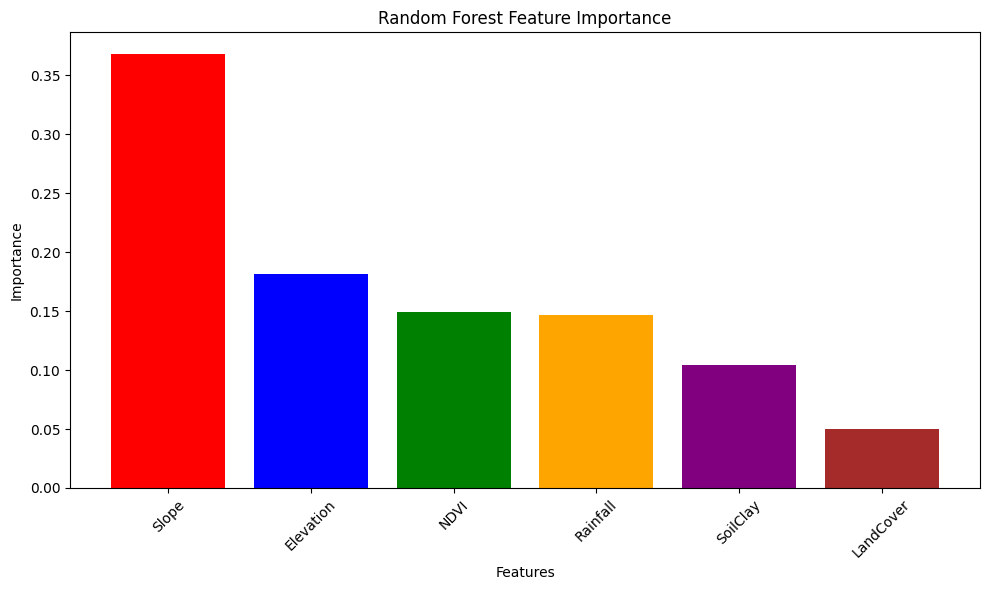

In [94]:
plt.figure(figsize=(10, 6))

colors = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown"
]

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"],
    color=colors
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [143]:
# XG-BOOSTING :
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [144]:
y_pred_xgb = xgb_model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nXGBoost Predicted values:")
print(y_pred_xgb)

Actual values:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

XGBoost Predicted values:
[0 0 0 1 1 0 1 1 0 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0
 1 0 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1
 0 1 0

In [146]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)

print("XGBoost Accuracy :", accuracy_xgb)
print("XGBoost Precision:", precision_xgb)
print("XGBoost Recall   :", recall_xgb)
print("XGBoost F1 Score :", f1_xgb)

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nXGBoost Classification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    zero_division=0
))

XGBoost Accuracy : 0.8169014084507042
XGBoost Precision: 0.24489795918367346
XGBoost Recall   : 0.4444444444444444
XGBoost F1 Score : 0.3157894736842105

XGBoost Confusion Matrix:
[[220  37]
 [ 15  12]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.89       257
           1       0.24      0.44      0.32        27

    accuracy                           0.82       284
   macro avg       0.59      0.65      0.61       284
weighted avg       0.87      0.82      0.84       284



In [149]:
#  XG-BOOST TUNING:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_tuned.fit(X_train, y_train)

print("Tuned XGBoost model trained successfully!")

Tuned XGBoost model trained successfully!


In [150]:
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nTuned XGBoost Predicted values:")
print(y_pred_xgb_tuned)

Actual values:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Tuned XGBoost Predicted values:
[0 0 0 1 1 0 1 1 0 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0
 1 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1


In [153]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(
    y_test, y_pred_xgb_tuned, zero_division=0
)
recall_xgb_tuned = recall_score(
    y_test, y_pred_xgb_tuned, zero_division=0
)
f1_xgb_tuned = f1_score(
    y_test, y_pred_xgb_tuned, zero_division=0
)

print("Tuned XGBoost Accuracy :", accuracy_xgb_tuned)
print("Tuned XGBoost Precision:", precision_xgb_tuned)
print("Tuned XGBoost Recall   :", recall_xgb_tuned)
print("Tuned XGBoost F1 Score :", f1_xgb_tuned)

print("\nTuned XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print("\nTuned XGBoost Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb_tuned,
        zero_division=0
    )
)

Tuned XGBoost Accuracy : 0.8345070422535211
Tuned XGBoost Precision: 0.2826086956521739
Tuned XGBoost Recall   : 0.48148148148148145
Tuned XGBoost F1 Score : 0.3561643835616438

Tuned XGBoost Confusion Matrix:
[[224  33]
 [ 14  13]]

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91       257
           1       0.28      0.48      0.36        27

    accuracy                           0.83       284
   macro avg       0.61      0.68      0.63       284
weighted avg       0.88      0.83      0.85       284



In [154]:
xgb_tuned_prob = xgb_tuned.predict_proba(X_test)[:, 1]

print("First 10 probabilities:")
print(xgb_tuned_prob[:10])

First 10 probabilities:
[0.25143206 0.35860568 0.08038524 0.8952718  0.5278252  0.49519703
 0.89133495 0.90620154 0.26874125 0.28225222]


In [155]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_pred_threshold = (xgb_tuned_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.3 | Precision: 0.253 | Recall: 0.741 | F1: 0.377
Threshold: 0.4 | Precision: 0.288 | Recall: 0.630 | F1: 0.395
Threshold: 0.5 | Precision: 0.283 | Recall: 0.481 | F1: 0.356
Threshold: 0.6 | Precision: 0.300 | Recall: 0.333 | F1: 0.316
Threshold: 0.7 | Precision: 0.471 | Recall: 0.296 | F1: 0.364


In [161]:
from sklearn.model_selection import GroupShuffleSplit

# Training data ke andar se validation split
train_groups = sample_groups[train_idx]

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=123
)

train_sub_idx, val_idx = next(
    gss_val.split(
        X_train,
        y_train,
        groups=train_groups
    )
)

X_train_sub = X_train.iloc[train_sub_idx]
X_val = X_train.iloc[val_idx]

y_train_sub = y_train.iloc[train_sub_idx]
y_val = y_train.iloc[val_idx]

print("Training subset:", X_train_sub.shape)
print("Validation data:", X_val.shape)

print("\nTraining subset target:")
print(y_train_sub.value_counts())

print("\nValidation target:")
print(y_val.value_counts())

print(
    "\nValidation grid cells:",
    len(set(train_groups[val_idx]))
)

Training subset: (1128, 6)
Validation data: (267, 6)

Training subset target:
landslide
1    604
0    524
Name: count, dtype: int64

Validation target:
landslide
0    175
1     92
Name: count, dtype: int64

Validation grid cells: 2


In [162]:
from xgboost import XGBClassifier

xgb_validation = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_validation.fit(
    X_train_sub,
    y_train_sub
)

print("Validation XGBoost trained successfully!")

Validation XGBoost trained successfully!


In [163]:
y_val_prob = xgb_validation.predict_proba(X_val)[:, 1]

print("First 10 validation probabilities:")
print(y_val_prob[:10])

First 10 validation probabilities:
[0.6173034  0.01062306 0.15735231 0.00794543 0.88432074 0.0030114
 0.02960047 0.6862105  0.6819359  0.16744256]


In [164]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.3 | Precision: 0.640 | Recall: 0.620 | F1: 0.630
Threshold: 0.4 | Precision: 0.691 | Recall: 0.609 | F1: 0.647
Threshold: 0.5 | Precision: 0.729 | Recall: 0.554 | F1: 0.630
Threshold: 0.6 | Precision: 0.763 | Recall: 0.489 | F1: 0.596
Threshold: 0.7 | Precision: 0.800 | Recall: 0.348 | F1: 0.485


In [165]:
# Final prediction on untouched test data

y_test_prob_final = xgb_validation.predict_proba(X_test)[:, 1]

# Use threshold selected from validation
final_threshold = 0.4

y_test_pred_final = (
    y_test_prob_final >= final_threshold
).astype(int)

print("Final threshold:", final_threshold)
print("First 20 final predictions:")
print(y_test_pred_final[:20])

Final threshold: 0.4
First 20 final predictions:
[1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1]


In [166]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_final = accuracy_score(
    y_test,
    y_test_pred_final
)

precision_final = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

recall_final = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

f1_final = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

print("Final Accuracy :", accuracy_final)
print("Final Precision:", precision_final)
print("Final Recall   :", recall_final)
print("Final F1 Score :", f1_final)

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_final,
        zero_division=0
    )
)

Final Accuracy : 0.8345070422535211
Final Precision: 0.3333333333333333
Final Recall   : 0.7407407407407407
Final F1 Score : 0.45977011494252873

Final Confusion Matrix:
[[217  40]
 [  7  20]]

Final Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       257
           1       0.33      0.74      0.46        27

    accuracy                           0.83       284
   macro avg       0.65      0.79      0.68       284
weighted avg       0.91      0.83      0.86       284



In [172]:
#  COMPARE BOTH MODEL:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [accuracy, accuracy_xgb],
    "Precision": [precision, precision_xgb],
    "Recall": [recall, recall_xgb],
    "F1 Score": [f1, f1_xgb]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.820423   0.847826  0.423913  0.565217
1        XGBoost  0.816901   0.244898  0.444444  0.315789


In [174]:
# Combine training + validation data

X_train_final = pd.concat(
    [X_train_sub, X_val]
).reset_index(drop=True)

y_train_final = pd.concat(
    [y_train_sub, y_val]
).reset_index(drop=True)

print("Final training data:", X_train_final.shape)
print("\nFinal target distribution:")
print(y_train_final.value_counts())

Final training data: (1395, 6)

Final target distribution:
landslide
0    699
1    696
Name: count, dtype: int64


In [175]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(
    X_train_final,
    y_train_final
)

print("Final Random Forest trained successfully!")

Final Random Forest trained successfully!


In [176]:
from xgboost import XGBClassifier

xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_final.fit(
    X_train_final,
    y_train_final
)

print("Final XGBoost trained successfully!")

Final XGBoost trained successfully!


In [177]:
# Features for Whole Assam prediction

X_prediction = prediction_df[
    [
        "Elevation",
        "Slope",
        "Rainfall",
        "NDVI",
        "SoilClay",
        "LandCover"
    ]
].copy()

print("Prediction feature shape:", X_prediction.shape)
print("\nMissing values:")
print(X_prediction.isna().sum())

Prediction feature shape: (4757, 6)

Missing values:
Elevation    0
Slope        0
Rainfall     0
NDVI         0
SoilClay     0
LandCover    0
dtype: int64


In [178]:
# Predict landslide probability using both final models

prediction_df["RF_Probability"] = (
    rf_final.predict_proba(X_prediction)[:, 1]
)

prediction_df["XGB_Probability"] = (
    xgb_final.predict_proba(X_prediction)[:, 1]
)

print(
    prediction_df[
        [
            "Latitude",
            "Longitude",
            "RF_Probability",
            "XGB_Probability"
        ]
    ].head(20)
)

     Latitude  Longitude  RF_Probability  XGB_Probability
0   25.641510  92.737250        0.247957         0.241944
1   24.364070  92.469280        0.485489         0.461565
2   26.178363  93.057473        0.028685         0.047191
3   26.559353  91.552897        0.000614         0.007361
4   26.031796  92.420509        0.464940         0.444185
5   26.489872  92.981141        0.074759         0.066113
6   26.229241  93.509842        0.265723         0.173107
7   26.752732  92.332953        0.070926         0.034919
8   26.386283  93.928968        0.015073         0.009822
9   26.727325  93.648025        0.077757         0.059424
10  26.334486  90.923509        0.014418         0.012781
11  26.914566  93.662863        0.008408         0.006182
12  26.793731  91.711380        0.208013         0.157260
13  25.629340  93.201909        0.123333         0.034664
14  27.368970  95.547296        0.008219         0.012602
15  26.792699  93.447321        0.141933         0.057950
16  26.696336 

In [179]:
# Risk classification using threshold 0.4

prediction_df["RF_Risk"] = (
    prediction_df["RF_Probability"] >= 0.4
).astype(int)

prediction_df["XGB_Risk"] = (
    prediction_df["XGB_Probability"] >= 0.4
).astype(int)

print("RF risk distribution:")
print(prediction_df["RF_Risk"].value_counts())

print("\nXGBoost risk distribution:")
print(prediction_df["XGB_Risk"].value_counts())

RF risk distribution:
RF_Risk
0    3957
1     800
Name: count, dtype: int64

XGBoost risk distribution:
XGB_Risk
0    4067
1     690
Name: count, dtype: int64


In [182]:
# Final prediction summary

prediction_result = prediction_df[
    [
        "Latitude",
        "Longitude",
        "RF_Probability",
        "XGB_Probability",
        "RF_Risk",
        "XGB_Risk"
    ]
].copy()

print("Prediction result shape:", prediction_result.shape)

print("\nFirst 20 predictions:")
print(prediction_result.head(20))

Prediction result shape: (4757, 6)

First 20 predictions:
     Latitude  Longitude  RF_Probability  XGB_Probability  RF_Risk  XGB_Risk
0   25.641510  92.737250        0.247957         0.241944        0         0
1   24.364070  92.469280        0.485489         0.461565        1         1
2   26.178363  93.057473        0.028685         0.047191        0         0
3   26.559353  91.552897        0.000614         0.007361        0         0
4   26.031796  92.420509        0.464940         0.444185        1         1
5   26.489872  92.981141        0.074759         0.066113        0         0
6   26.229241  93.509842        0.265723         0.173107        0         0
7   26.752732  92.332953        0.070926         0.034919        0         0
8   26.386283  93.928968        0.015073         0.009822        0         0
9   26.727325  93.648025        0.077757         0.059424        0         0
10  26.334486  90.923509        0.014418         0.012781        0         0
11  26.914566  93.

In [183]:
# High-risk locations according to both models

high_risk = prediction_result[
    (prediction_result["RF_Probability"] >= 0.4) &
    (prediction_result["XGB_Probability"] >= 0.4)
].copy()

print("High-risk points detected by both models:", len(high_risk))

print("\nTop 20 high-risk locations:")
print(
    high_risk.sort_values(
        by="XGB_Probability",
        ascending=False
    ).head(20)
)

High-risk points detected by both models: 645

Top 20 high-risk locations:
       Latitude  Longitude  RF_Probability  XGB_Probability  RF_Risk  XGB_Risk
2713  26.184691  91.858334        0.964532         0.983106        1         1
1127  26.162437  92.019916        0.973664         0.979578        1         1
2415  26.149830  92.788738        0.974719         0.973555        1         1
4645  25.439133  93.408262        0.946811         0.971888        1         1
3568  26.148579  91.704649        0.974090         0.971781        1         1
1337  26.215028  91.867107        0.969683         0.971622        1         1
2458  25.932961  91.431460        0.947014         0.971598        1         1
1226  25.181714  93.079514        0.971057         0.970617        1         1
2753  26.146563  92.896875        0.937461         0.969244        1         1
1420  26.091877  92.065650        0.955936         0.968478        1         1
978   25.207258  93.220807        0.911180         0.968

In [184]:
# Save Whole Assam prediction results

output_file = r"C:\Users\shubh\OneDrive\Documents\hack\assam_landslide_predictions.csv"

prediction_result.to_csv(
    output_file,
    index=False
)

print("Prediction results saved successfully!")
print(output_file)

Prediction results saved successfully!
C:\Users\shubh\OneDrive\Documents\hack\assam_landslide_predictions.csv


In [181]:
# rf_importance = pd.DataFrame({
#     "Feature": X.columns,
#     "Random Forest": rf_model.feature_importances_
# })

# xgb_importance = pd.DataFrame({
#     "Feature": X.columns,
#     "XGBoost": xgb_model.feature_importances_
# })

# importance_compare = rf_importance.merge(
#     xgb_importance,
#     on="Feature"
# )

# print(importance_compare)

In [180]:
# importance_compare.plot(
#     x="Feature",
#     y=["Random Forest", "XGBoost"],
#     kind="bar",
#     figsize=(12, 6)
# )

# plt.title("Feature Importance: Random Forest vs XGBoost")
# plt.xlabel("Features")
# plt.ylabel("Importance")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [187]:
#  1 cell
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

np.random.seed(123)

n_prediction = 5000
prediction_points = []

minx, miny, maxx, maxy = polygon.bounds

while len(prediction_points) < n_prediction:

    lon = np.random.uniform(minx, maxx)
    lat = np.random.uniform(miny, maxy)

    point = Point(lon, lat)

    if polygon.contains(point):
        prediction_points.append(point)

prediction_gdf = gpd.GeoDataFrame(
    geometry=prediction_points,
    crs="EPSG:4326"
)

prediction_gdf["Longitude"] = prediction_gdf.geometry.x
prediction_gdf["Latitude"] = prediction_gdf.geometry.y

print("Whole Assam prediction points:", len(prediction_gdf))
prediction_gdf.head()

Whole Assam prediction points: 5000


,geometry,Longitude,Latitude
0,POINT (91.12992 26.25324),91.129919,26.253245
1,POINT (92.73725 25.64151),92.737250,25.641510
2,POINT (92.46928 24.36407),92.469280,24.364070
3,POINT (93.05747 26.17836),93.057473,26.178363
4,POINT (91.5529 26.55935),91.552897,26.559353


In [188]:

# 5000 prediction points ko GEE FeatureCollection mein convert karo

prediction_features = []

for _, row in prediction_gdf.iterrows():

    point = ee.Geometry.Point([
        float(row["Longitude"]),
        float(row["Latitude"])
    ])

    prediction_features.append(
        ee.Feature(
            point,
            {
                "Latitude": float(row["Latitude"]),
                "Longitude": float(row["Longitude"])
            }
        )
    )

prediction_points_ee = ee.FeatureCollection(prediction_features)

print(
    "GEE prediction points:",
    prediction_points_ee.size().getInfo()
)

GEE prediction points: 5000


In [194]:
prediction_sampled = feature_image.sampleRegions(
    collection=prediction_points_ee,
    properties=[
        "Latitude",
        "Longitude"
    ],
    scale=30,
    geometries=False
)

prediction_df = geemap.ee_to_df(
    prediction_sampled
)

print(
    "Prediction dataset shape:",
    prediction_df.shape
)

print(
    prediction_df.head()
)

Prediction dataset shape: (4757, 8)
   Elevation  LandCover   Latitude  Longitude      NDVI   Rainfall     Slope  \
0        394         10  25.641510  92.737250  0.754813   5.785641  0.927410   
1         92         10  24.364070  92.469280  0.702965  10.618792  4.224407   
2         86         10  26.178363  93.057473  0.535070   5.232432  2.122489   
3         63         40  26.559353  91.552897  0.476404   5.346306  2.270593   
4        645         10  26.031796  92.420509  0.664417   5.127140  5.467624   

   SoilClay  
0       304  
1       276  
2       288  
3       246  
4       331  


In [195]:
X_prediction = prediction_df[
    [
        "Elevation",
        "Slope",
        "Rainfall",
        "NDVI",
        "SoilClay",
        "LandCover"
    ]
].copy()

print(
    "Prediction feature shape:",
    X_prediction.shape
)

print("\nMissing values:")
print(
    X_prediction.isna().sum()
)

Prediction feature shape: (4757, 6)

Missing values:
Elevation    0
Slope        0
Rainfall     0
NDVI         0
SoilClay     0
LandCover    0
dtype: int64


In [196]:
# Final Random Forest probability

prediction_df["RF_Probability"] = (
    rf_final.predict_proba(
        X_prediction
    )[:, 1]
)

# Final XGBoost probability

prediction_df["XGB_Probability"] = (
    xgb_final.predict_proba(
        X_prediction
    )[:, 1]
)

print(
    prediction_df[
        [
            "Latitude",
            "Longitude",
            "RF_Probability",
            "XGB_Probability"
        ]
    ].head(20)
)

     Latitude  Longitude  RF_Probability  XGB_Probability
0   25.641510  92.737250        0.247957         0.241944
1   24.364070  92.469280        0.485489         0.461565
2   26.178363  93.057473        0.028685         0.047191
3   26.559353  91.552897        0.000614         0.007361
4   26.031796  92.420509        0.464940         0.444185
5   26.489872  92.981141        0.074759         0.066113
6   26.229241  93.509842        0.265723         0.173107
7   26.752732  92.332953        0.070926         0.034919
8   26.386283  93.928968        0.015073         0.009822
9   26.727325  93.648025        0.077757         0.059424
10  26.334486  90.923509        0.014418         0.012781
11  26.914566  93.662863        0.008408         0.006182
12  26.793731  91.711380        0.208013         0.157260
13  25.629340  93.201909        0.123333         0.034664
14  27.368970  95.547296        0.008219         0.012602
15  26.792699  93.447321        0.141933         0.057950
16  26.696336 

In [197]:
def risk_category(probability):

    if probability < 0.20:
        return "Low"

    elif probability < 0.40:
        return "Medium"

    elif probability < 0.70:
        return "High"

    else:
        return "Very High"


# XGBoost risk

prediction_df["XGB_Risk"] = (
    prediction_df["XGB_Probability"]
    .apply(risk_category)
)

# Random Forest risk

prediction_df["RF_Risk"] = (
    prediction_df["RF_Probability"]
    .apply(risk_category)
)


print("XGBoost Risk Distribution:")
print(
    prediction_df["XGB_Risk"].value_counts()
)

print("\nRandom Forest Risk Distribution:")
print(
    prediction_df["RF_Risk"].value_counts()
)

XGBoost Risk Distribution:
XGB_Risk
Low          3557
Medium        510
High          420
Very High     270
Name: count, dtype: int64

Random Forest Risk Distribution:
RF_Risk
Low          3241
Medium        716
High          552
Very High     248
Name: count, dtype: int64


In [198]:
risk_features = []

for i, row in prediction_df.iterrows():

    point = ee.Geometry.Point([
        float(row["Longitude"]),
        float(row["Latitude"])
    ])

    risk_features.append(
        ee.Feature(
            point,
            {
                "Point_ID": int(i),

                "RF_Probability": float(
                    row["RF_Probability"]
                ),

                "XGB_Probability": float(
                    row["XGB_Probability"]
                ),

                "RF_Risk": str(
                    row["RF_Risk"]
                ),

                "XGB_Risk": str(
                    row["XGB_Risk"]
                )
            }
        )
    )

risk_fc = ee.FeatureCollection(
    risk_features
)

print(
    "Total risk points:",
    risk_fc.size().getInfo()
)

Total risk points: 4757


In [199]:
low_risk = risk_fc.filter(
    ee.Filter.eq(
        "XGB_Risk",
        "Low"
    )
)

medium_risk = risk_fc.filter(
    ee.Filter.eq(
        "XGB_Risk",
        "Medium"
    )
)

high_risk = risk_fc.filter(
    ee.Filter.eq(
        "XGB_Risk",
        "High"
    )
)

very_high_risk = risk_fc.filter(
    ee.Filter.eq(
        "XGB_Risk",
        "Very High"
    )
)

print(
    "Low:",
    low_risk.size().getInfo()
)

print(
    "Medium:",
    medium_risk.size().getInfo()
)

print(
    "High:",
    high_risk.size().getInfo()
)

print(
    "Very High:",
    very_high_risk.size().getInfo()
)

Low: 3557
Medium: 510
High: 420
Very High: 270


In [201]:
assam_ee = states.filter(
    ee.Filter.eq(
        "ADM1_NAME",
        "Assam"
    )
)

print(
    "Assam boundary:",
    assam_ee.size().getInfo()
)

Assam boundary: 1


In [202]:
Risk_Map = geemap.Map()

Risk_Map.center_object(
    assam_ee,
    8
)

# Assam Boundary

Risk_Map.addLayer(
    assam_ee.style(
        color="000000",
        fillColor="00000000",
        width=2
    ),
    {},
    "Assam Boundary"
)

# Low Risk

Risk_Map.addLayer(
    low_risk,
    {
        "color": "00FF00",
        "pointSize": 4
    },
    "Low Risk"
)

# Medium Risk

Risk_Map.addLayer(
    medium_risk,
    {
        "color": "FFFF00",
        "pointSize": 4
    },
    "Medium Risk"
)

# High Risk

Risk_Map.addLayer(
    high_risk,
    {
        "color": "FFA500",
        "pointSize": 5
    },
    "High Risk"
)

# Very High Risk

Risk_Map.addLayer(
    very_high_risk,
    {
        "color": "FF0000",
        "pointSize": 6
    },
    "Very High Risk"
)

Risk_Map

# 🟢 Low
# 🟡 Medium
# 🟠 High
# 🔴 Very High

Map(center=[26.352060685710303, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

In [203]:
actual_landslide_features = []

for _, row in landslides.iterrows():

    point = ee.Geometry.Point([
        float(row["Longitude"]),
        float(row["Latitude"])
    ])

    actual_landslide_features.append(
        ee.Feature(
            point,
            {
                "Slide_No": str(
                    row["Slide_No"]
                ),

                "Slide_Name": str(
                    row["Slide_Name"]
                ),

                "Latitude": float(
                    row["Latitude"]
                ),

                "Longitude": float(
                    row["Longitude"]
                )
            }
        )
    )

actual_landslide_fc = ee.FeatureCollection(
    actual_landslide_features
)

print(
    "Actual Whole Assam GSI landslides:",
    actual_landslide_fc.size().getInfo()
)

Actual Whole Assam GSI landslides: 856


In [204]:
Map_compare = geemap.Map()

Map_compare.center_object(
    assam_ee,
    8
)

# Actual GSI landslides

Map_compare.addLayer(
    actual_landslide_fc,
    {
        "color": "0000FF",
        "pointSize": 6
    },
    "Actual GSI Landslides"
)

# Very High predicted risk

Map_compare.addLayer(
    very_high_risk,
    {
        "color": "FF0000",
        "pointSize": 6
    },
    "Very High Predicted Risk"
)

Map_compare

# 🔵 Blue = historical GSI landslide locations
# 🔴 Red = model predicted Very High risk locations

Map(center=[26.352060685710303, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

In [205]:
top_risk = prediction_df.sort_values(
    by="XGB_Probability",
    ascending=False
)

print(
    top_risk[
        [
            "Latitude",
            "Longitude",
            "RF_Probability",
            "XGB_Probability",
            "RF_Risk",
            "XGB_Risk"
        ]
    ].head(20)
)

       Latitude  Longitude  RF_Probability  XGB_Probability    RF_Risk  \
2713  26.184691  91.858334        0.964532         0.983106  Very High   
1127  26.162437  92.019916        0.973664         0.979578  Very High   
2415  26.149830  92.788738        0.974719         0.973555  Very High   
4645  25.439133  93.408262        0.946811         0.971888  Very High   
3568  26.148579  91.704649        0.974090         0.971781  Very High   
1337  26.215028  91.867107        0.969683         0.971622  Very High   
2458  25.932961  91.431460        0.947014         0.971598  Very High   
1226  25.181714  93.079514        0.971057         0.970617  Very High   
2753  26.146563  92.896875        0.937461         0.969244  Very High   
1420  26.091877  92.065650        0.955936         0.968478  Very High   
978   25.207258  93.220807        0.911180         0.968016  Very High   
1050  26.098459  92.120059        0.955000         0.967470  Very High   
1441  25.282673  93.223765        0.95

In [206]:
# 14 cell
output_file = r"C:\Users\shubh\OneDrive\Documents\hack\assam_landslide_risk_predictions.csv"

prediction_df.to_csv(
    output_file,
    index=False
)

print(
    "Complete prediction results saved successfully!"
)

print(
    "File:",
    output_file
)

Complete prediction results saved successfully!
File: C:\Users\shubh\OneDrive\Documents\hack\assam_landslide_risk_predictions.csv


In [207]:
# GEE training points
# Historical landslides = 1
# Background points = 0

training_points = (
    landslide_points_ee
    .merge(negative_points_ee)
)

print(
    "Total GEE training points:",
    training_points.size().getInfo()
)

Total GEE training points: 1856


In [208]:
# Extract 6 environmental features
# for every training point

training_samples = feature_image.sampleRegions(
    collection=training_points,
    properties=["landslide"],
    scale=30,
    geometries=False,
    tileScale=4
)

print(
    "GEE training samples:",
    training_samples.size().getInfo()
)

GEE training samples: 1721


In [209]:
# Train Random Forest inside GEE

gee_rf = ee.Classifier.smileRandomForest(
    numberOfTrees=300,
    seed=42
).train(
    features=training_samples,
    classProperty="landslide",
    inputProperties=[
        "Elevation",
        "Slope",
        "Rainfall",
        "NDVI",
        "SoilClay",
        "LandCover"
    ]
)

print(
    "GEE Random Forest trained successfully!"
)

GEE Random Forest trained successfully!


In [210]:
# Apply trained GEE Random Forest
# to the complete Assam feature image

gee_prediction = feature_image.classify(
    gee_rf
)

print(
    "Whole Assam prediction completed!"
)

Whole Assam prediction completed!


In [211]:
# Create Whole Assam susceptibility map

GEE_Risk_Map = geemap.Map()

GEE_Risk_Map.center_object(
    assam_ee,
    8
)

# Add Assam boundary

GEE_Risk_Map.addLayer(
    assam_ee.style(
        color="000000",
        fillColor="00000000",
        width=2
    ),
    {},
    "Assam Boundary"
)

# Add GEE prediction

GEE_Risk_Map.addLayer(
    gee_prediction,
    {
        "min": 0,
        "max": 1,
        "palette": [
            "00FF00",
            "FFFF00",
            "FFA500",
            "FF0000"
        ]
    },
    "GEE Landslide Susceptibility"
)

GEE_Risk_Map

# 🟢 Low
# 🟡 Medium
# 🟠 High
# 🔴 Very High

Map(center=[26.352060685710285, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

In [212]:
# Actual GSI landslide locations
# over the GEE susceptibility map

GEE_Actual_Map = geemap.Map()

GEE_Actual_Map.center_object(
    assam_ee,
    8
)

# Susceptibility map

GEE_Actual_Map.addLayer(
    gee_prediction,
    {
        "min": 0,
        "max": 1,
        "palette": [
            "00FF00",
            "FFFF00",
            "FFA500",
            "FF0000"
        ]
    },
    "Landslide Susceptibility"
)

# Actual GSI landslides

GEE_Actual_Map.addLayer(
    actual_landslide_fc,
    {
        "color": "0000FF",
        "pointSize": 5
    },
    "Actual GSI Landslides"
)

GEE_Actual_Map

Map(center=[26.352060685710303, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

In [213]:
gee_prediction = feature_image.classify(
    gee_rf
)

print("Whole Assam prediction completed!")

Whole Assam prediction completed!


In [214]:
GEE_Risk_Map = geemap.Map()

GEE_Risk_Map.center_object(
    assam_ee,
    8
)

GEE_Risk_Map.addLayer(
    assam_ee.style(
        color="000000",
        fillColor="00000000",
        width=2
    ),
    {},
    "Assam Boundary"
)

GEE_Risk_Map.addLayer(
    gee_prediction,
    {
        "min": 0,
        "max": 1,
        "palette": [
            "00FF00",
            "FFFF00",
            "FFA500",
            "FF0000"
        ]
    },
    "Landslide Susceptibility"
)

GEE_Risk_Map

Map(center=[26.352060685710303, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

In [215]:
GEE_Actual_Map = geemap.Map()

GEE_Actual_Map.center_object(
    assam_ee,
    8
)

GEE_Actual_Map.addLayer(
    gee_prediction,
    {
        "min": 0,
        "max": 1,
        "palette": [
            "00FF00",
            "FFFF00",
            "FFA500",
            "FF0000"
        ]
    },
    "Landslide Susceptibility"
)

GEE_Actual_Map.addLayer(
    actual_landslide_fc,
    {
        "color": "0000FF",
        "pointSize": 5
    },
    "Actual GSI Landslides"
)

GEE_Actual_Map

Map(center=[26.352060685710285, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

In [217]:
!pip install rasterio

   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   -- ------------------------------------- 1.8/25.7 MB 10.1 MB/s eta 0:00:03
   ------- -------------------------------- 4.7/25.7 MB 11.9 MB/s eta 0:00:02
   ------------ --------------------------- 7.9/25.7 MB 12.8 MB/s eta 0:00:02
   ---------------- ----------------------- 10.7/25.7 MB 13.4 MB/s eta 0:00:02
   -------------------- ------------------- 13.1/25.7 MB 13.1 MB/s eta 0:00:01
   ------------------------ --------------- 15.5/25.7 MB 12.6 MB/s eta 0:00:01
   --------------------------- ------------ 17.6/25.7 MB 12.4 MB/s eta 0:00:01
   ------------------------------ --------- 19.7/25.7 MB 12.1 MB/s eta 0:00:01
   --------------------------------- ------ 21.8/25.7 MB 11.9 MB/s eta 0:00:01
   ------------------------------------- -- 24.1/25.7 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 25.7/25.7 MB 11.6 MB/s  0:00:02

   ------------------------------ --------- 3/4 [rasterio]
   ----

In [219]:
!pip uninstall rasterio -y
!pip install --upgrade pip
!pip install rasterio

Found existing installation: rasterio 1.4.4
Uninstalling rasterio-1.4.4:
  Successfully uninstalled rasterio-1.4.4
  Using cached rasterio-1.4.4-cp310-cp310-win_amd64.whl.metadata (9.6 kB)
Using cached rasterio-1.4.4-cp310-cp310-win_amd64.whl (25.7 MB)


In [221]:
import rasterio
import numpy as np
import pandas as pd

raster_file = r"OneDrive/Documents/hack/Assam_6Feature_Predictors_100m.tif"

src = rasterio.open(raster_file)

print("Raster opened successfully")
print("Bands:", src.count)
print("Width:", src.width)
print("Height:", src.height)
print("CRS:", src.crs)
print("Feature names:", src.descriptions)

Raster opened successfully
Bands: 6
Width: 7043
Height: 4279
CRS: EPSG:4326
Feature names: ('Elevation', 'Slope', 'Rainfall', 'NDVI', 'SoilClay', 'LandCover')


In [222]:
# Read the 6 feature bands

data = src.read()

print("Raster data shape:", data.shape)

Raster data shape: (6, 4279, 7043)


In [223]:
# Convert raster data into ML input format

bands, height, width = data.shape

X_raster = data.reshape(bands, -1).T

print("X_raster shape:", X_raster.shape)

X_raster shape: (30136997, 6)


In [224]:
# Predict landslide probability in chunks

chunk_size = 100000
xgb_probability = np.empty(X_raster.shape[0], dtype=np.float32)

for start in range(0, X_raster.shape[0], chunk_size):
    end = min(start + chunk_size, X_raster.shape[0])

    xgb_probability[start:end] = (
        xgb_final.predict_proba(
            X_raster[start:end]
        )[:, 1]
    )

print("XGBoost prediction completed")
print("Total predictions:", len(xgb_probability))
print("Minimum probability:", xgb_probability.min())
print("Maximum probability:", xgb_probability.max())

XGBoost prediction completed
Total predictions: 30136997
Minimum probability: 0.0030299316
Maximum probability: 0.9965389


In [225]:
# Convert XGBoost probabilities back to raster shape

probability_raster = xgb_probability.reshape(height, width)

print("Probability raster shape:", probability_raster.shape)
print("Minimum:", probability_raster.min())
print("Maximum:", probability_raster.max())

Probability raster shape: (4279, 7043)
Minimum: 0.0030299316
Maximum: 0.9965389


In [226]:
# Save XGBoost probability map as GeoTIFF

output_tif = r"C:\Users\shubh\Downloads\Assam_XGBoost_Landslide_Probability.tif"

profile = src.profile.copy()

profile.update(
    dtype=rasterio.float32,
    count=1,
    compress="lzw",
    nodata=-9999
)

with rasterio.open(output_tif, "w", **profile) as dst:
    dst.write(
        probability_raster.astype(rasterio.float32),
        1
    )

print("XGBoost probability GeoTIFF saved successfully!")
print("File:", output_tif)

XGBoost probability GeoTIFF saved successfully!
File: C:\Users\shubh\Downloads\Assam_XGBoost_Landslide_Probability.tif
